<a href="https://colab.research.google.com/github/garlich/Data/blob/main/3_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 3: Linear Regression**
### Chicago Crime & Weather Analysis

Predict `total_crimes` per day from weather + calendar features

In [33]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('TF version:', tf.__version__)
print('Ready :)')

TF version: 2.20.0
Ready :)


## Part A: Load + prepare the data

In [34]:
# A1: load CSV from GitHub
url = 'https://raw.githubusercontent.com/garlich/Data/main/chicago_crime_weather_2017_2024.csv'
df = pd.read_csv(url)
df['crime_date'] = pd.to_datetime(df['crime_date'])
print(f'Shape: {df.shape}')
df.head()

Shape: (2920, 38)


,crime_date,day_of_week,month,year,day_of_year,is_weekend,is_holiday,total_crimes,total_arrests,domestic_crimes,...,visibility_miles,wind_speed_knots,max_wind_speed_knots,gust_speed_knots,precipitation_in,snow_depth_in,fog,rain_drizzle,snow_ice_pellets,thunder
0,2017-01-01,1,1,2017,1,1,1,1281,168,416,...,9.5,4.5,11.1,15.9,0.00,NaN,0,0,0,0
1,2017-01-02,2,1,2017,2,0,0,613,110,131,...,7.2,5.2,8.0,NaN,0.00,NaN,0,1,0,0
2,2017-01-03,3,1,2017,3,0,0,721,133,137,...,2.4,5.9,18.1,22.9,0.11,NaN,1,1,0,0
3,2017-01-04,4,1,2017,4,0,0,614,108,116,...,9.7,14.9,18.1,28.0,0.00,NaN,0,0,0,0
4,2017-01-05,5,1,2017,5,0,0,612,115,111,...,9.9,11.5,17.1,19.0,0.00,NaN,0,0,1,0


In [35]:
# A2: feature engineering
weather_features = ['mean_temp_f', 'precipitation_in', 'wind_speed_knots', 'visibility_miles']

df_dow   = pd.get_dummies(df['day_of_week'], prefix='dow').astype(float)
df_month = pd.get_dummies(df['month'],       prefix='month').astype(float)

# combine (dropping covid_period as it hurts prediction on the post-covid test year)
X = pd.concat([
    df[weather_features].astype(float),
    df_dow,
    df_month,
    df[['is_weekend', 'is_holiday']].astype(float)
], axis=1)
y = df['total_crimes'].astype(float)

print(f'Feature matrix shape: {X.shape}')
print(f'Dtypes unique: {X.dtypes.unique()}')
print(f'Any NaN: {X.isna().any().any()}')

Feature matrix shape: (2920, 25)
Dtypes unique: [dtype('float64')]
Any NaN: False


In [36]:
# A3: temporal train/test split
# train: 2017-2023, test: 2024 (full balanced year)
train_mask = df['year'] <= 2023
test_mask  = df['year'] == 2024

X_train, X_test = X[train_mask].values.astype(float), X[test_mask].values.astype(float)
y_train, y_test = y[train_mask].values.astype(float), y[test_mask].values.astype(float)

print(f'Train: {X_train.shape[0]} days (2017-2023)')
print(f'Test:  {X_test.shape[0]} days (2024)')

Train: 2554 days (2017-2023)
Test:  366 days (2024)


# Part B: Build + train the model

In [41]:
# B1: manual normalisation (mean/std from training data only)
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
X_std[X_std == 0] = 1   # avoid divide by zero on any constant columns

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

# also normalise the target so the loss numbers are sane
y_mean = y_train.mean()
y_std  = y_train.std()
y_train_norm = (y_train - y_mean) / y_std

print(f'Train mean after norm: {X_train_norm.mean():.4f}')
print(f'Train std after norm:  {X_train_norm.std():.4f}')

# B2: simple linear regression model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_norm.shape[1],)),
    tf.keras.layers.Dense(1)
])
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    loss      = 'mean_squared_error',
    metrics   = ['mean_absolute_error']
)
model.summary()

Train mean after norm: 0.0000
Train std after norm:  1.0000


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# B3: train with early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,
    restore_best_weights = True
)

history = model.fit(
    X_train_norm, y_train_norm,
    validation_split = 0.2,
    epochs           = 200,
    callbacks        = [early_stop],
    verbose          = 0
)
print(f'Trained for {len(history.history["loss"])} epochs')
print(f'Final train loss: {history.history["loss"][-1]:.4f}')
print(f'Final val loss:   {history.history["val_loss"][-1]:.4f}')

Trained for 22 epochs
Final train loss: 0.8933
Final val loss:   0.4496


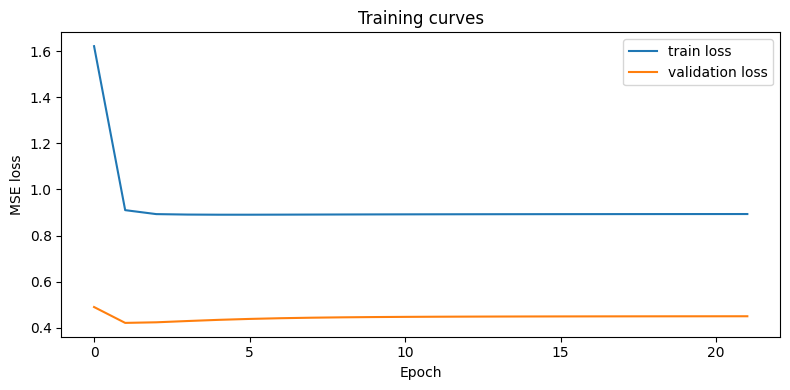

In [43]:
# B4: training curves (loss over epochs)
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training curves')
plt.legend()
plt.tight_layout()
plt.show()

# Part C: Evaluate on the 2024 test set

In [44]:
# C1: predict on test set + compute metrics
y_pred_norm = model.predict(X_test_norm, verbose=0).flatten()
y_pred = y_pred_norm * y_std + y_mean   # denormalise

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'2024 test set ({len(y_test)} days):')
print(f'  RMSE: {rmse:.1f}  (avg error in crimes/day)')
print(f'  MAE:  {mae:.1f}  (median-style error)')
print(f'  R2:   {r2:.3f}  (fraction of variance explained)')

2024 test set (366 days):
  RMSE: 71.0  (avg error in crimes/day)
  MAE:  50.3  (median-style error)
  R2:   0.285  (fraction of variance explained)


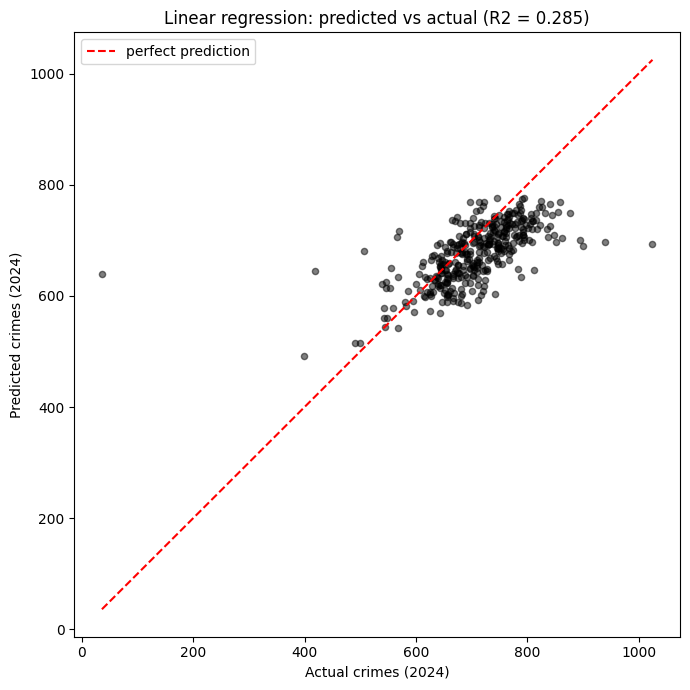

In [45]:
# C2: predicted vs actual scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, s=20, color='black')
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], 'r--', label='perfect prediction')
plt.xlabel('Actual crimes (2024)')
plt.ylabel('Predicted crimes (2024)')
plt.title(f'Linear regression: predicted vs actual (R2 = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

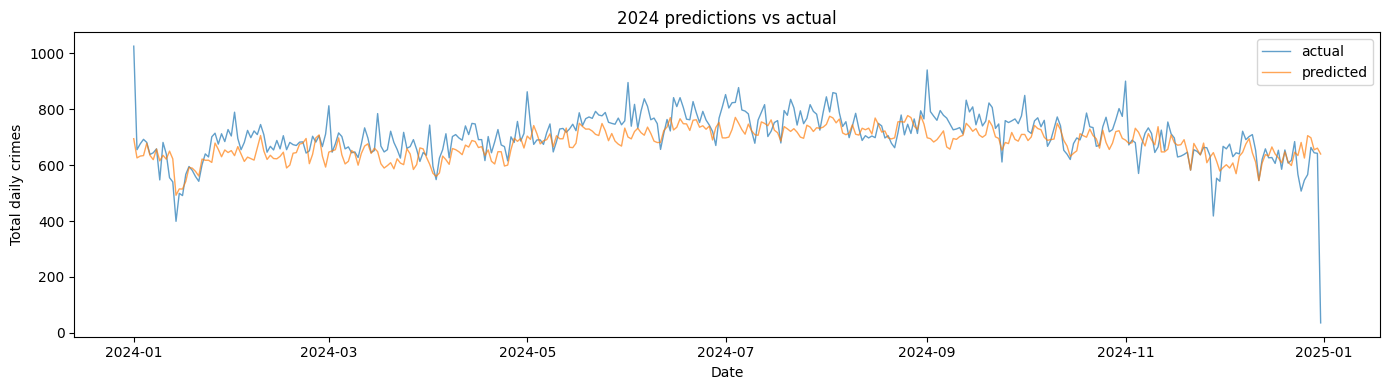

In [46]:
# C3: predictions over time (visual check)
test_dates = df.loc[test_mask, 'crime_date'].values
plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test, label='actual', alpha=0.7, linewidth=1)
plt.plot(test_dates, y_pred, label='predicted', alpha=0.7, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Total daily crimes')
plt.title('2024 predictions vs actual')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# C4: find the worst predictions (where the model was most wrong)
errors = pd.DataFrame({
    'date':      df.loc[test_mask, 'crime_date'].values,
    'dow':       df.loc[test_mask, 'day_of_week'].values,
    'month':     df.loc[test_mask, 'month'].values,
    'temp':      df.loc[test_mask, 'mean_temp_f'].values,
    'precip':    df.loc[test_mask, 'precipitation_in'].values,
    'actual':    y_test,
    'predicted': y_pred,
    'error':     y_test - y_pred
})

print('Top 5 underpredictions (model said much LOWER than actual):')
print(errors.nlargest(5, 'error')[['date','dow','month','temp','precip','actual','predicted','error']].to_string(index=False))

print('\nTop 5 overpredictions (model said much HIGHER than actual):')
print(errors.nsmallest(5, 'error')[['date','dow','month','temp','precip','actual','predicted','error']].to_string(index=False))

Top 5 underpredictions (model said much LOWER than actual):
      date  dow  month  temp  precip  actual  predicted      error
2024-01-01    2      1  31.5    0.08  1025.0 694.253562 330.746438
2024-09-01    1      9  72.1    0.00   940.0 697.556472 242.443528
2024-11-01    6     11  45.6    0.03   900.0 689.288863 210.711137
2024-06-01    7      6  66.2    0.00   895.0 700.246554 194.753446
2024-03-01    6      3  39.3    0.00   812.0 646.482794 165.517206

Top 5 overpredictions (model said much HIGHER than actual):
      date  dow  month  temp  precip  actual  predicted       error
2024-12-31    3     12  38.9    0.23    36.0 639.605047 -603.605047
2024-11-28    5     11  31.8    0.00   418.0 644.573313 -226.573313
2024-12-25    4     12  34.5    0.00   507.0 680.860412 -173.860412
2024-11-05    3     11  64.8    1.01   570.0 717.153230 -147.153230
2024-12-27    6     12  47.2    0.05   566.0 705.222067 -139.222067


Largest underpredictions tend to be specific dates suggesting maybe events, that weather + day-of-week features can't capture. Largest overpredictions are days where weather suggested more crime but actuals were lower

In [48]:
# D1: predict on hand-crafted scenarios
feature_names = list(X.columns)

# warm summer Friday in July
row1 = pd.Series(0, index=feature_names, dtype=float)
row1['mean_temp_f']      = 80
row1['precipitation_in'] = 0
row1['wind_speed_knots'] = 8
row1['visibility_miles'] = 10
row1['dow_6']            = 1   # Friday
row1['month_7']          = 1   # July
row1_norm = (row1.values - X_mean) / X_std
pred_1 = model.predict(row1_norm.reshape(1, -1).astype(float), verbose=0)[0, 0]
pred_1 = pred_1 * y_std + y_mean
print(f'Warm summer Friday (80F, no rain): predicted {pred_1:.0f} crimes')

# cold rainy Sunday in January
row2 = pd.Series(0, index=feature_names, dtype=float)
row2['mean_temp_f']      = 20
row2['precipitation_in'] = 0.5
row2['wind_speed_knots'] = 15
row2['visibility_miles'] = 3
row2['dow_1']            = 1   # Sunday
row2['month_1']          = 1   # January
row2['is_weekend']       = 1
row2_norm = (row2.values - X_mean) / X_std
pred_2 = model.predict(row2_norm.reshape(1, -1).astype(float), verbose=0)[0, 0]
pred_2 = pred_2 * y_std + y_mean
print(f'Cold rainy Sunday (20F, rain): predicted {pred_2:.0f} crimes')

print(f'\nDifference: {pred_1 - pred_2:.0f} more crimes on the warm Friday')

Warm summer Friday (80F, no rain): predicted 770 crimes
Cold rainy Sunday (20F, rain): predicted 565 crimes

Difference: 205 more crimes on the warm Friday


# Summary

Linear regression on 2017-2023, tested on 2024 (366 days)

- RMSE: 71 crimes/day
- MAE: 50 crimes/day
- R2: 0.285

Hand-crafted predictions:

- Warm summer Friday: 770 crimes, cold winter
- Sunday: 565 crimes (a 205 crime difference, matching the weather + day-of-week effects)
- Covid_period was dropped from features after testing/debugging because it hurt 2024 predictions despite improving in-sample fit
